In [ ]:
# ── 1: imports e configurações ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
from pathlib import Path

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ── 2: carregamento do star schema ─────────────────────────────────────
dim_date        = pd.read_csv(RAW / "dim_date.csv")
dim_product     = pd.read_csv(RAW / "dim_product.csv")
dim_region      = pd.read_csv(RAW / "dim_region.csv")
dim_customer    = pd.read_csv(RAW / "dim_customer.csv")
dim_salesperson = pd.read_csv(RAW / "dim_salesperson.csv")
fact            = pd.read_csv(RAW / "fact_transactions.csv")

print("Star schema loaded:")
print(f"  fact_transactions: {len(fact):,} rows")
print(f"  dim_date:          {len(dim_date):,} rows")
print(f"  dim_product:       {len(dim_product):,} rows")
print(f"  dim_region:        {len(dim_region):,} rows")
print(f"  dim_customer:      {len(dim_customer):,} rows")
print(f"  dim_salesperson:   {len(dim_salesperson):,} rows")

Star schema loaded:
  fact_transactions: 5,000 rows
  dim_date:          1,096 rows
  dim_product:       20 rows
  dim_region:        5 rows
  dim_customer:      200 rows
  dim_salesperson:   30 rows


In [3]:
# ── 3: registro no DuckDB ──────────────────────────────────────────────
con = duckdb.connect()
con.register("fact",            fact)
con.register("dim_date",        dim_date)
con.register("dim_product",     dim_product)
con.register("dim_region",      dim_region)
con.register("dim_customer",    dim_customer)
con.register("dim_salesperson", dim_salesperson)

# KPIs gerais
kpis = con.execute("""
    SELECT
        ROUND(SUM(revenue), 2)                        AS total_revenue,
        ROUND(SUM(profit), 2)                         AS total_profit,
        ROUND(SUM(profit) / SUM(revenue) * 100, 1)   AS profit_margin_pct,
        COUNT(DISTINCT transaction_id)                AS total_transactions,
        COUNT(DISTINCT customer_id)                   AS unique_customers
    FROM fact
""").df()

print("── Global KPIs ──")
print(f"  Total Revenue:      ${kpis['total_revenue'][0]:>15,.2f}")
print(f"  Total Profit:       ${kpis['total_profit'][0]:>15,.2f}")
print(f"  Profit Margin:       {kpis['profit_margin_pct'][0]:>14.1f}%")
print(f"  Total Transactions:  {kpis['total_transactions'][0]:>15,}")
print(f"  Unique Customers:    {kpis['unique_customers'][0]:>15,}")

── Global KPIs ──
  Total Revenue:      $ 217,784,019.30
  Total Profit:       $ 113,950,474.54
  Profit Margin:                 52.3%
  Total Transactions:            5,000
  Unique Customers:                200


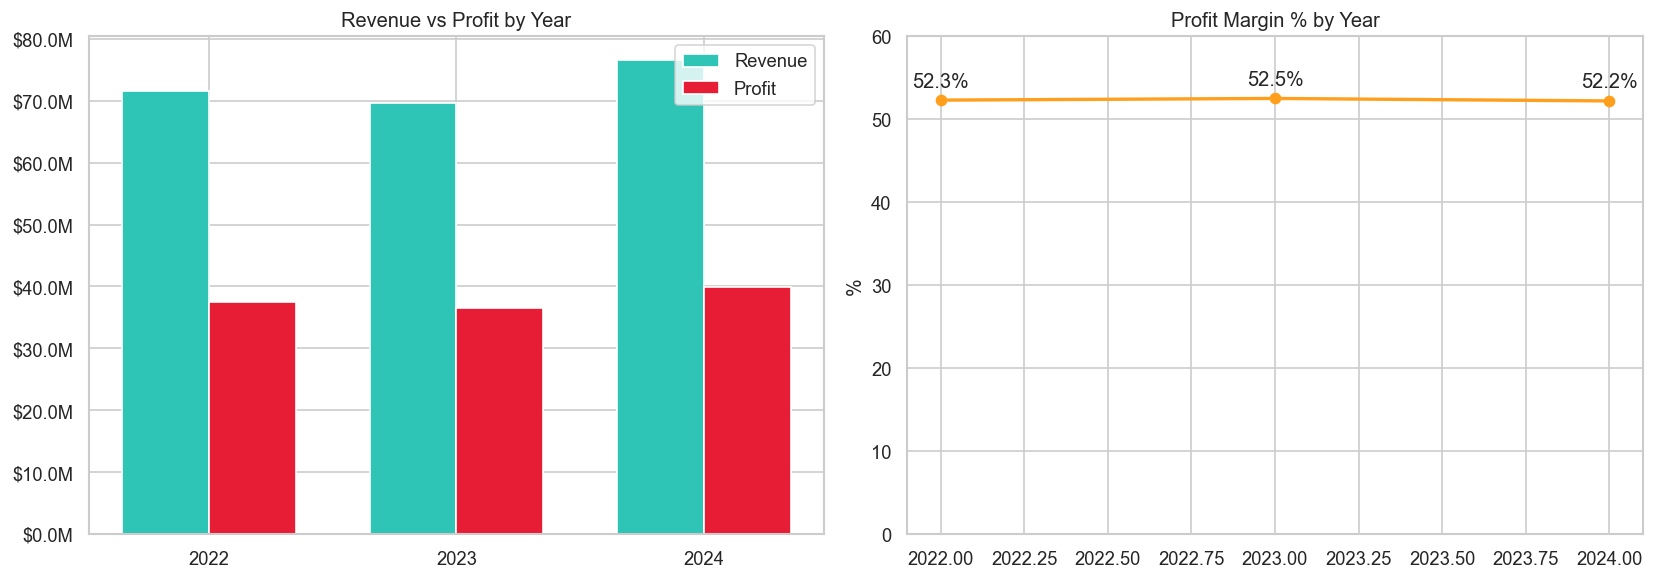

 year     revenue      profit  margin_pct  yoy_growth
 2022 71532310.28 37413641.23        52.3         NaN
 2023 69674869.53 36574920.42        52.5   -2.596646
 2024 76576839.49 39961912.89        52.2    9.905968


In [4]:
# ── 4: revenue e profit por ano ───────────────────────────────────────
yearly = con.execute("""
    SELECT
        d.year,
        ROUND(SUM(f.revenue), 2) AS revenue,
        ROUND(SUM(f.profit), 2)  AS profit,
        ROUND(SUM(f.profit) / SUM(f.revenue) * 100, 1) AS margin_pct
    FROM fact f
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.year
    ORDER BY d.year
""").df()

# YoY Growth
yearly["yoy_growth"] = yearly["revenue"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Profit por ano
x = np.arange(len(yearly))
w = 0.35
axes[0].bar(x - w/2, yearly["revenue"] / 1e6, w, label="Revenue", color="#2EC4B6")
axes[0].bar(x + w/2, yearly["profit"] / 1e6,  w, label="Profit",  color="#E71D36")
axes[0].set_xticks(x)
axes[0].set_xticklabels(yearly["year"])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f}M"))
axes[0].set_title("Revenue vs Profit by Year")
axes[0].legend()

# Profit Margin por ano
axes[1].plot(yearly["year"], yearly["margin_pct"], marker="o", lw=2, color="#FF9F1C")
axes[1].set_title("Profit Margin % by Year")
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 60)
for i, row in yearly.iterrows():
    axes[1].annotate(f"{row['margin_pct']}%", (row["year"], row["margin_pct"]),
                     textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("../outputs/yearly_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(yearly.to_string(index=False))

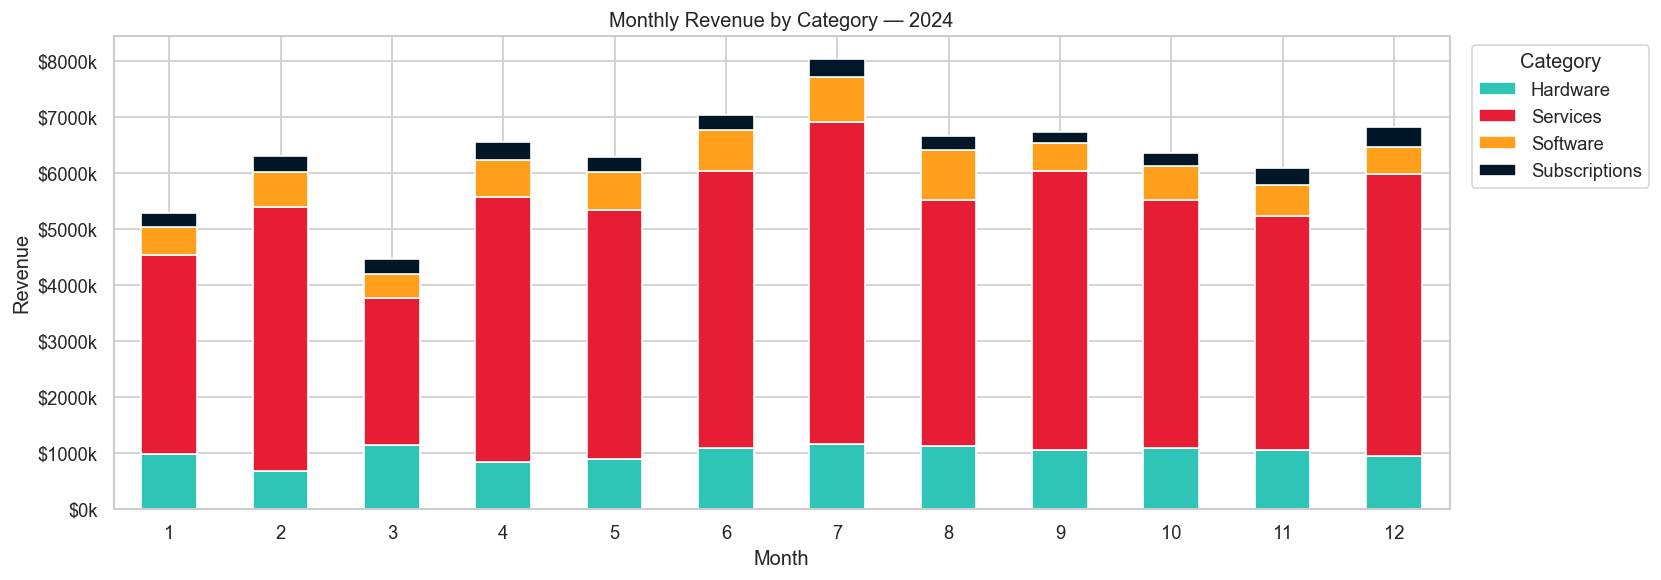

In [5]:
# ── 5: revenue por categoria e mês (stacked) ──────────────────────────
monthly_cat = con.execute("""
    SELECT
        d.year,
        d.month,
        p.category,
        ROUND(SUM(f.revenue), 2) AS revenue
    FROM fact f
    JOIN dim_date d    ON f.date_id    = d.date_id
    JOIN dim_product p ON f.product_id = p.product_id
    WHERE d.year = 2024
    GROUP BY d.year, d.month, p.category
    ORDER BY d.month, p.category
""").df()

pivot = monthly_cat.pivot(index="month", columns="category", values="revenue").fillna(0)

colors = ["#2EC4B6", "#E71D36", "#FF9F1C", "#011627"]
ax = pivot.plot(kind="bar", stacked=True, figsize=(14, 5), color=colors)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.set_title("Monthly Revenue by Category — 2024")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.set_xticklabels([str(m) for m in pivot.index], rotation=0)
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/monthly_category.png", dpi=150, bbox_inches="tight")
plt.show()

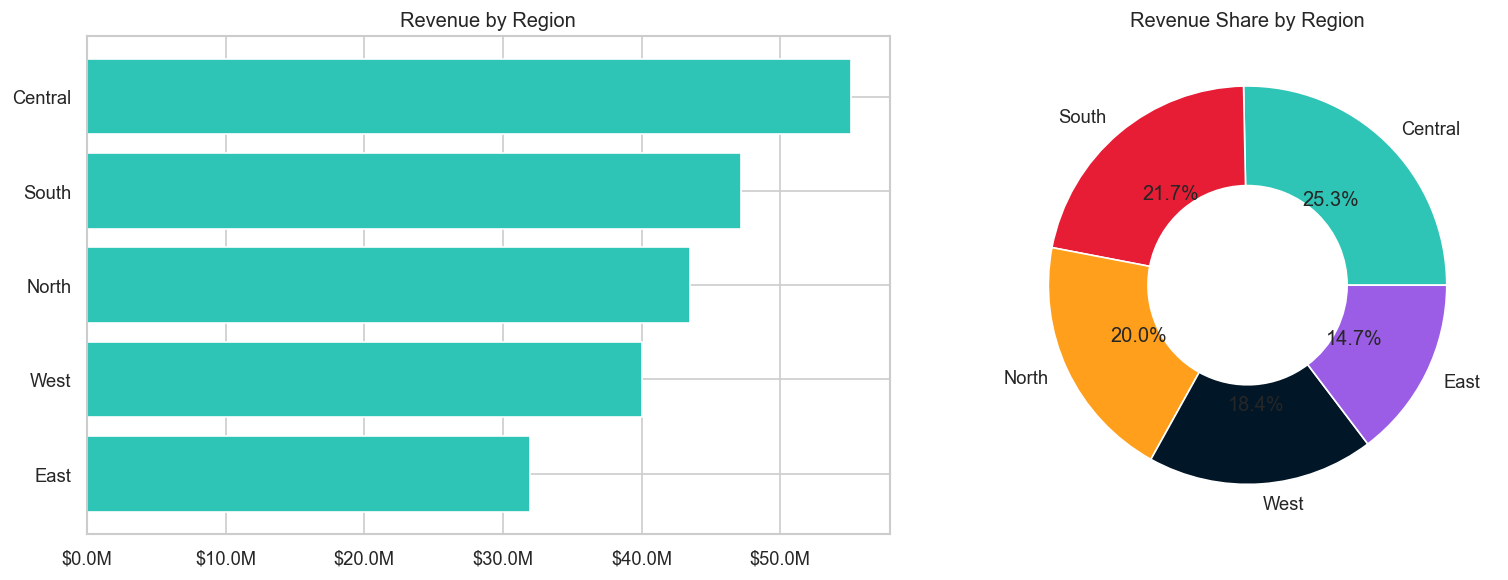

 region     revenue      profit  margin_pct  transactions
Central 55141147.23 29027394.99        52.6          1207
  South 47165999.19 24325560.42        51.6          1064
  North 43472493.23 22623333.47        52.0          1024
   West 40031806.62 21135244.24        52.8           977
   East 31972573.03 16838941.42        52.7           728


In [6]:
# ── 6: revenue por região ─────────────────────────────────────────────
by_region = con.execute("""
    SELECT
        r.region,
        ROUND(SUM(f.revenue), 2)  AS revenue,
        ROUND(SUM(f.profit), 2)   AS profit,
        ROUND(SUM(f.profit) / SUM(f.revenue) * 100, 1) AS margin_pct,
        COUNT(DISTINCT f.transaction_id) AS transactions
    FROM fact f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    JOIN dim_region r   ON c.region_id   = r.region_id
    GROUP BY r.region
    ORDER BY revenue DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras horizontais
axes[0].barh(by_region["region"][::-1], by_region["revenue"][::-1] / 1e6, color="#2EC4B6")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f}M"))
axes[0].set_title("Revenue by Region")

# Rosca
wedges, texts, autotexts = axes[1].pie(
    by_region["revenue"],
    labels=by_region["region"],
    autopct="%1.1f%%",
    colors=["#2EC4B6", "#E71D36", "#FF9F1C", "#011627", "#9B5DE5"],
    wedgeprops={"width": 0.5}
)
axes[1].set_title("Revenue Share by Region")

plt.tight_layout()
plt.savefig("../outputs/region_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(by_region.to_string(index=False))

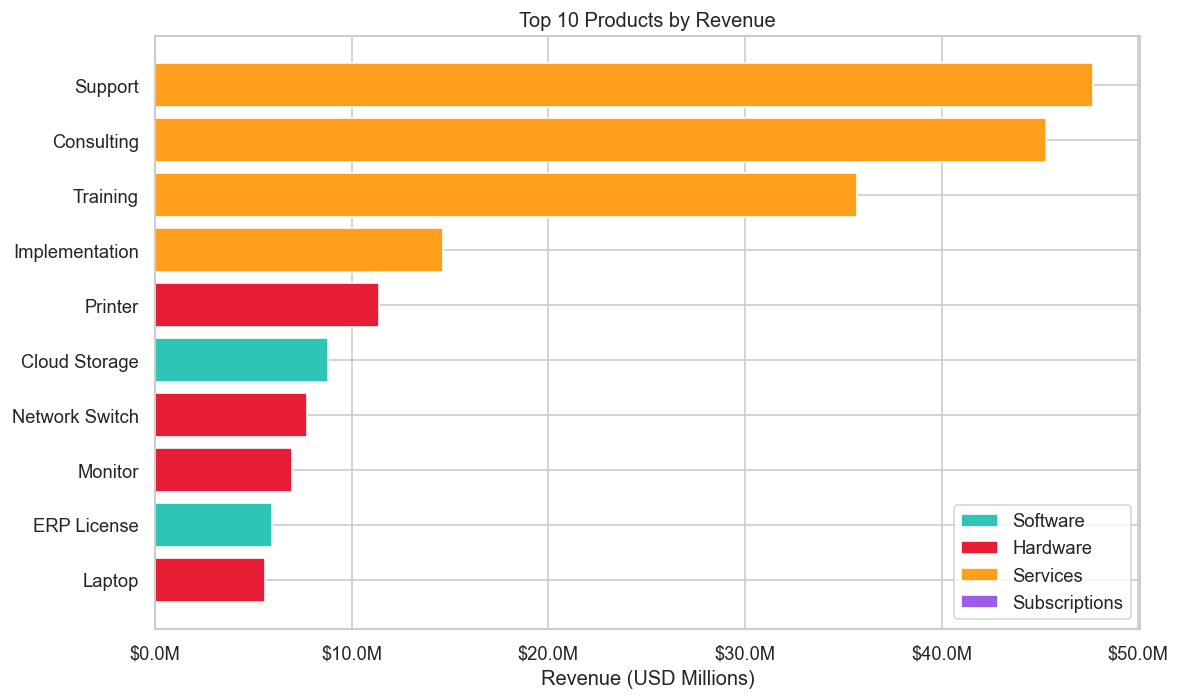

In [7]:
# ── 7: top 10 produtos por revenue ────────────────────────────────────
top_products = con.execute("""
    SELECT
        p.product_name,
        p.category,
        ROUND(SUM(f.revenue), 2)  AS revenue,
        ROUND(SUM(f.profit), 2)   AS profit,
        ROUND(SUM(f.profit) / SUM(f.revenue) * 100, 1) AS margin_pct,
        SUM(f.quantity)           AS units_sold
    FROM fact f
    JOIN dim_product p ON f.product_id = p.product_id
    GROUP BY p.product_name, p.category
    ORDER BY revenue DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
colors_map = {"Software": "#2EC4B6", "Hardware": "#E71D36",
              "Services": "#FF9F1C", "Subscriptions": "#9B5DE5"}
bar_colors = [colors_map[c] for c in top_products["category"][::-1]]
ax.barh(top_products["product_name"][::-1], top_products["revenue"][::-1] / 1e6,
        color=bar_colors)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f}M"))
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (USD Millions)")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("../outputs/top_products.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── 8: salvar dados processados para o Power BI ───────────────────────

# Tabela fato enriquecida
fact_enriched = con.execute("""
    SELECT
        f.transaction_id,
        f.date_id,
        d.date,
        d.year,
        d.quarter,
        d.month,
        d.month_name,
        f.product_id,
        p.product_name,
        p.category,
        f.customer_id,
        c.company_name,
        c.segment,
        r.region,
        f.salesperson_id,
        s.name AS salesperson_name,
        s.seniority,
        f.quantity,
        f.revenue,
        f.cost,
        f.profit,
        ROUND(f.profit / f.revenue * 100, 1) AS margin_pct
    FROM fact f
    JOIN dim_date d        ON f.date_id        = d.date_id
    JOIN dim_product p     ON f.product_id     = p.product_id
    JOIN dim_customer c    ON f.customer_id    = c.customer_id
    JOIN dim_region r      ON c.region_id      = r.region_id
    JOIN dim_salesperson s ON f.salesperson_id = s.salesperson_id
""").df()

fact_enriched.to_csv(PROCESSED / "fact_enriched.csv", index=False, encoding="utf-8-sig")
by_region.to_csv(PROCESSED / "region_summary.csv",    index=False, encoding="utf-8-sig")
top_products.to_csv(PROCESSED / "top_products.csv",   index=False, encoding="utf-8-sig")
yearly.to_csv(PROCESSED / "yearly_summary.csv",       index=False, encoding="utf-8-sig")

print("Files saved in data/processed/")
print(f"  fact_enriched:   {len(fact_enriched):,} rows x {len(fact_enriched.columns)} columns")
print(f"  region_summary:  {len(by_region)} rows")
print(f"  top_products:    {len(top_products)} rows")
print(f"  yearly_summary:  {len(yearly)} rows")

Files saved in data/processed/
  fact_enriched:   5,000 rows x 22 columns
  region_summary:  5 rows
  top_products:    10 rows
  yearly_summary:  3 rows
